<a href="https://colab.research.google.com/github/AshutoshJaiswal11/sharing_for_learning/blob/main/Financial_Analysis_CBSL2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <center>Analysis of Financial Statements: XYZ Bank<center>


In [1]:
# Import the necessary libraries

import os
import pandas as pd
import matplotlib.pyplot as plt
import cufflinks as cf
import numpy as np


import missingno
import datetime as dt

import warnings
warnings.filterwarnings('ignore')
import plotly.express
import time

In [2]:


# Automatically detects where it's running
if os.path.exists('/content/drive/MyDrive/Financial_Template_2026.xlsx'):
    # Running as original owner with Drive mounted
    df1 = pd.read_excel('/content/drive/MyDrive/Financial_Template_2026.xlsx',index_col=0, parse_dates=True)
else:
    # Running from GitHub - reads from repo
    url = 'https://raw.githubusercontent.com/AshutoshJaiswal11/sharing_for_learning/main/Financial_Template_2026.xlsx'
    df1 = pd.read_excel(url,index_col=0, parse_dates=True)



In [3]:
df1

,2013-03-31,2014-03-31,2015-03-31,2016-03-31,2017-03-31,2018-03-31,2019-03-31,2020-03-31,2021-03-31,2022-03-31,2023-03-31,2024-03-31,2025-03-31,2026-03-31
ITEMS,,,,,,,,,,,,,,
Paid up capital,14.570,14.840,15.640,15.83,15.220,15.38,16.13,18.35,20.15,21.43,23.39,24.74,24.41,23.94
Reserve Fund & other Reserves,88.200,92.570,95.940,100.25,104.740,111.22,118.13,128.60,139.95,202.13,216.46,222.17,262.25,263.76
Principal / Subsi. State Partner fund A/c,0.000,0.000,0.000,0.00,0.000,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
Deposits,565.150,642.560,746.980,872.88,1039.180,1142.61,1355.43,1366.59,1498.51,1663.26,1967.72,2071.38,2206.13,2530.66
Borrowings,59.930,119.880,69.940,23.98,0.000,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
Overdue Interest Reserve,1.960,1.640,1.370,1.44,1.590,2.76,4.07,4.21,4.14,3.99,4.03,4.30,4.64,4.75
Interest Payable,0.590,0.720,0.910,0.89,0.880,1.09,1.21,1.19,0.21,0.30,0.24,0.24,0.25,0.18
Other Liabilities,11.060,13.910,16.700,20.66,20.030,24.26,22.49,25.69,29.62,29.32,112.66,23.39,40.27,17.03
Profit or (Loss),4.520,4.670,5.670,5.94,7.850,7.20,9.96,10.25,12.03,14.34,12.42,12.80,13.54,18.42


In [4]:
df2=pd.DataFrame(df1)
print(f'Latest available Financial Year data: {str(df2.columns[-1].date())}')

# Extracting FY as column names

df2.columns = [df2.columns[i].date() for i in range(len(df2.columns))]

Latest available Financial Year data: 2026-03-31


In [5]:
df2

,2013-03-31,2014-03-31,2015-03-31,2016-03-31,2017-03-31,2018-03-31,2019-03-31,2020-03-31,2021-03-31,2022-03-31,2023-03-31,2024-03-31,2025-03-31,2026-03-31
ITEMS,,,,,,,,,,,,,,
Paid up capital,14.570,14.840,15.640,15.83,15.220,15.38,16.13,18.35,20.15,21.43,23.39,24.74,24.41,23.94
Reserve Fund & other Reserves,88.200,92.570,95.940,100.25,104.740,111.22,118.13,128.60,139.95,202.13,216.46,222.17,262.25,263.76
Principal / Subsi. State Partner fund A/c,0.000,0.000,0.000,0.00,0.000,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
Deposits,565.150,642.560,746.980,872.88,1039.180,1142.61,1355.43,1366.59,1498.51,1663.26,1967.72,2071.38,2206.13,2530.66
Borrowings,59.930,119.880,69.940,23.98,0.000,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
Overdue Interest Reserve,1.960,1.640,1.370,1.44,1.590,2.76,4.07,4.21,4.14,3.99,4.03,4.30,4.64,4.75
Interest Payable,0.590,0.720,0.910,0.89,0.880,1.09,1.21,1.19,0.21,0.30,0.24,0.24,0.25,0.18
Other Liabilities,11.060,13.910,16.700,20.66,20.030,24.26,22.49,25.69,29.62,29.32,112.66,23.39,40.27,17.03
Profit or (Loss),4.520,4.670,5.670,5.94,7.850,7.20,9.96,10.25,12.03,14.34,12.42,12.80,13.54,18.42


# 1. Financial Perfromance Analysis

We are looking at time series data and examining YoY change for lastest FY data

In [6]:
# Computing % change in last FY BS items over previous year

df2.fillna(0)
df2['% change'] = np.round((np.divide(np.array(df2.iloc[:,-1:]), np.array(df2.iloc[:,-2:-1]))-1)*100,2)
df2.fillna(0, inplace = True)


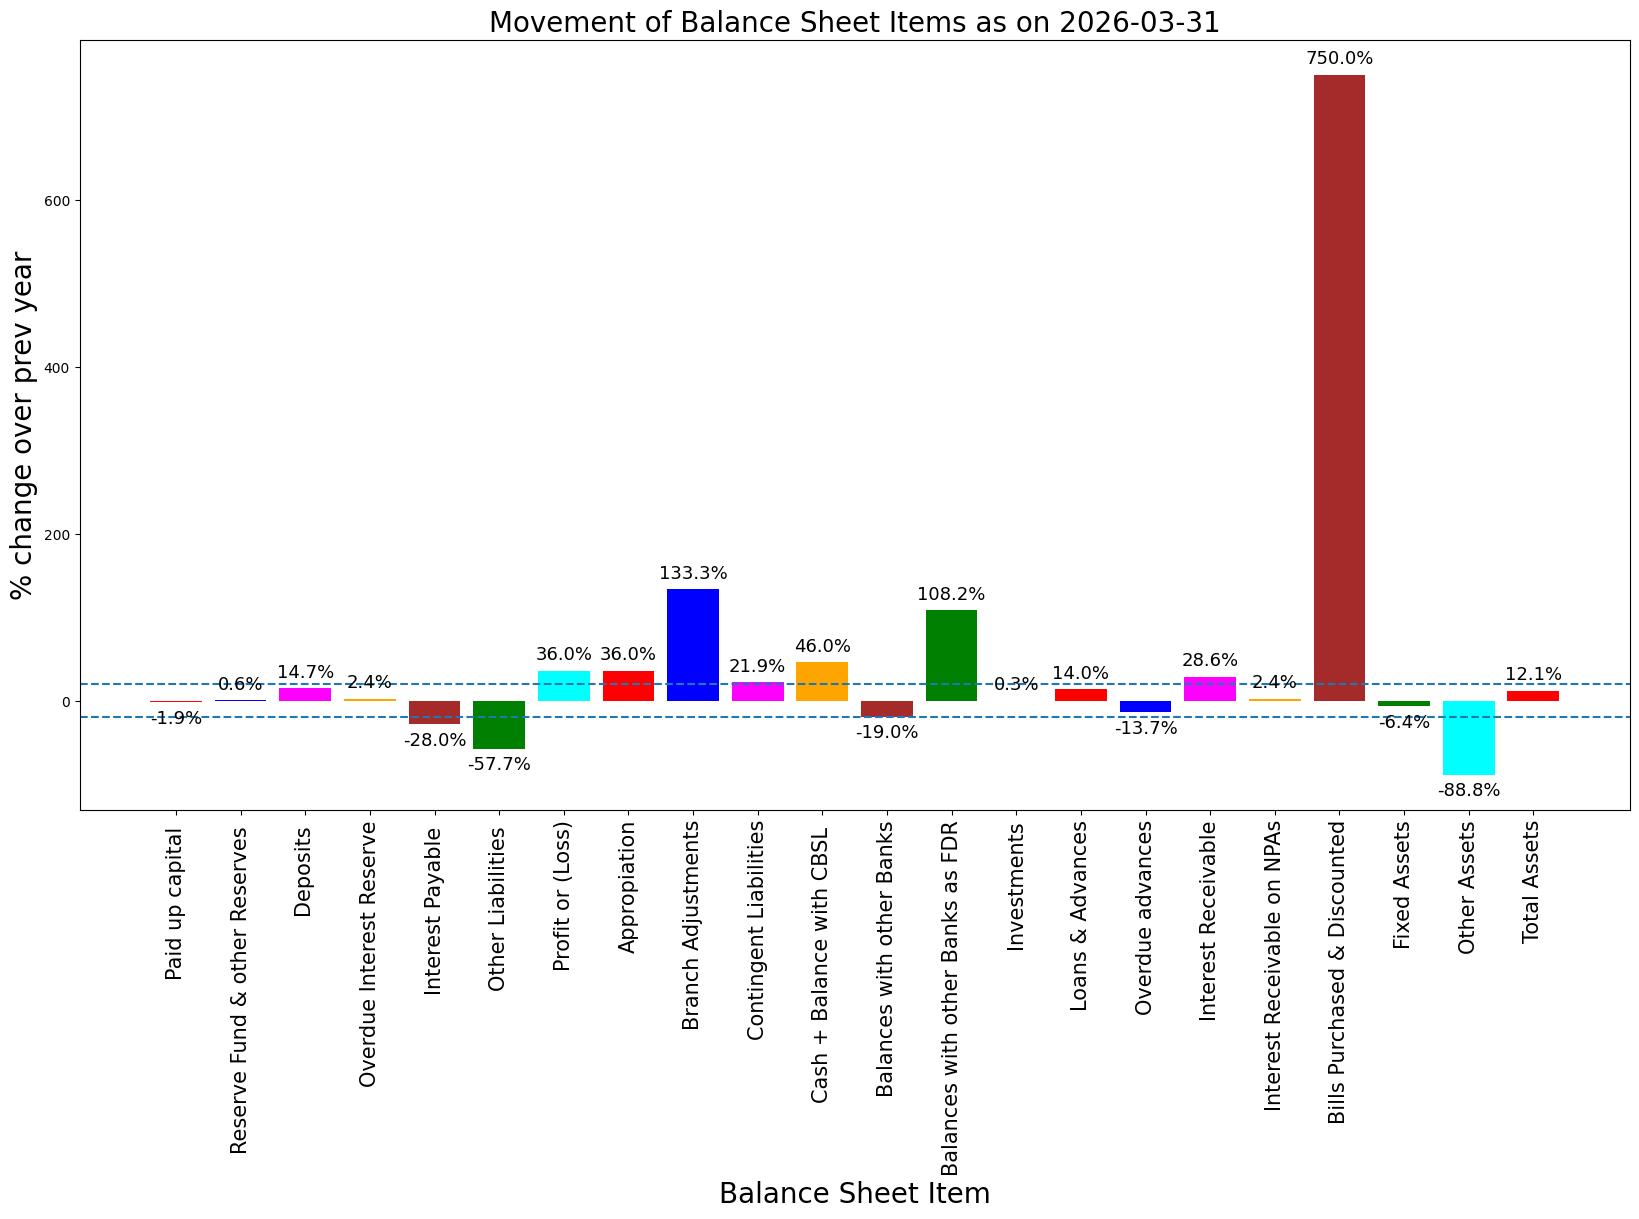

In [7]:

# Plotting change in all BS items

fig = plt.figure(figsize=(20, 10))

c = ['red', 'blue', 'magenta', 'orange', 'brown', 'green', 'cyan']

bars = plt.bar(df2.index[np.abs(df2['% change']!=0)], df2['% change'][np.abs(df2['% change']!=0)], color=c)

# Add value labels
plt.bar_label(bars, fmt='%.1f%%', padding=5, fontsize=13)

plt.xticks(rotation=90, fontsize=15)
plt.axhline(-20, linestyle='dashed')
plt.axhline(20, linestyle='dashed')

plt.xlabel('Balance Sheet Item', fontsize=20)
plt.ylabel('% change over prev year', fontsize=20)
plt.title(f'Movement of Balance Sheet Items as on {df2.columns[-2]}', fontsize=20)
plt.show()

In [8]:
# re-frame the data file for further processing

df2.drop(['% change'], axis = 1, inplace= True)
col_ind = [df2.columns[i] for i in range(len(df2.columns))]
df2

,2013-03-31,2014-03-31,2015-03-31,2016-03-31,2017-03-31,2018-03-31,2019-03-31,2020-03-31,2021-03-31,2022-03-31,2023-03-31,2024-03-31,2025-03-31,2026-03-31
ITEMS,,,,,,,,,,,,,,
Paid up capital,14.570,14.840,15.640,15.83,15.220,15.38,16.13,18.35,20.15,21.43,23.39,24.74,24.41,23.94
Reserve Fund & other Reserves,88.200,92.570,95.940,100.25,104.740,111.22,118.13,128.60,139.95,202.13,216.46,222.17,262.25,263.76
Principal / Subsi. State Partner fund A/c,0.000,0.000,0.000,0.00,0.000,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
Deposits,565.150,642.560,746.980,872.88,1039.180,1142.61,1355.43,1366.59,1498.51,1663.26,1967.72,2071.38,2206.13,2530.66
Borrowings,59.930,119.880,69.940,23.98,0.000,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
Overdue Interest Reserve,1.960,1.640,1.370,1.44,1.590,2.76,4.07,4.21,4.14,3.99,4.03,4.30,4.64,4.75
Interest Payable,0.590,0.720,0.910,0.89,0.880,1.09,1.21,1.19,0.21,0.30,0.24,0.24,0.25,0.18
Other Liabilities,11.060,13.910,16.700,20.66,20.030,24.26,22.49,25.69,29.62,29.32,112.66,23.39,40.27,17.03
Profit or (Loss),4.520,4.670,5.670,5.94,7.850,7.20,9.96,10.25,12.03,14.34,12.42,12.80,13.54,18.42


### 1.1 Visualizing Financial Parameters of Interest

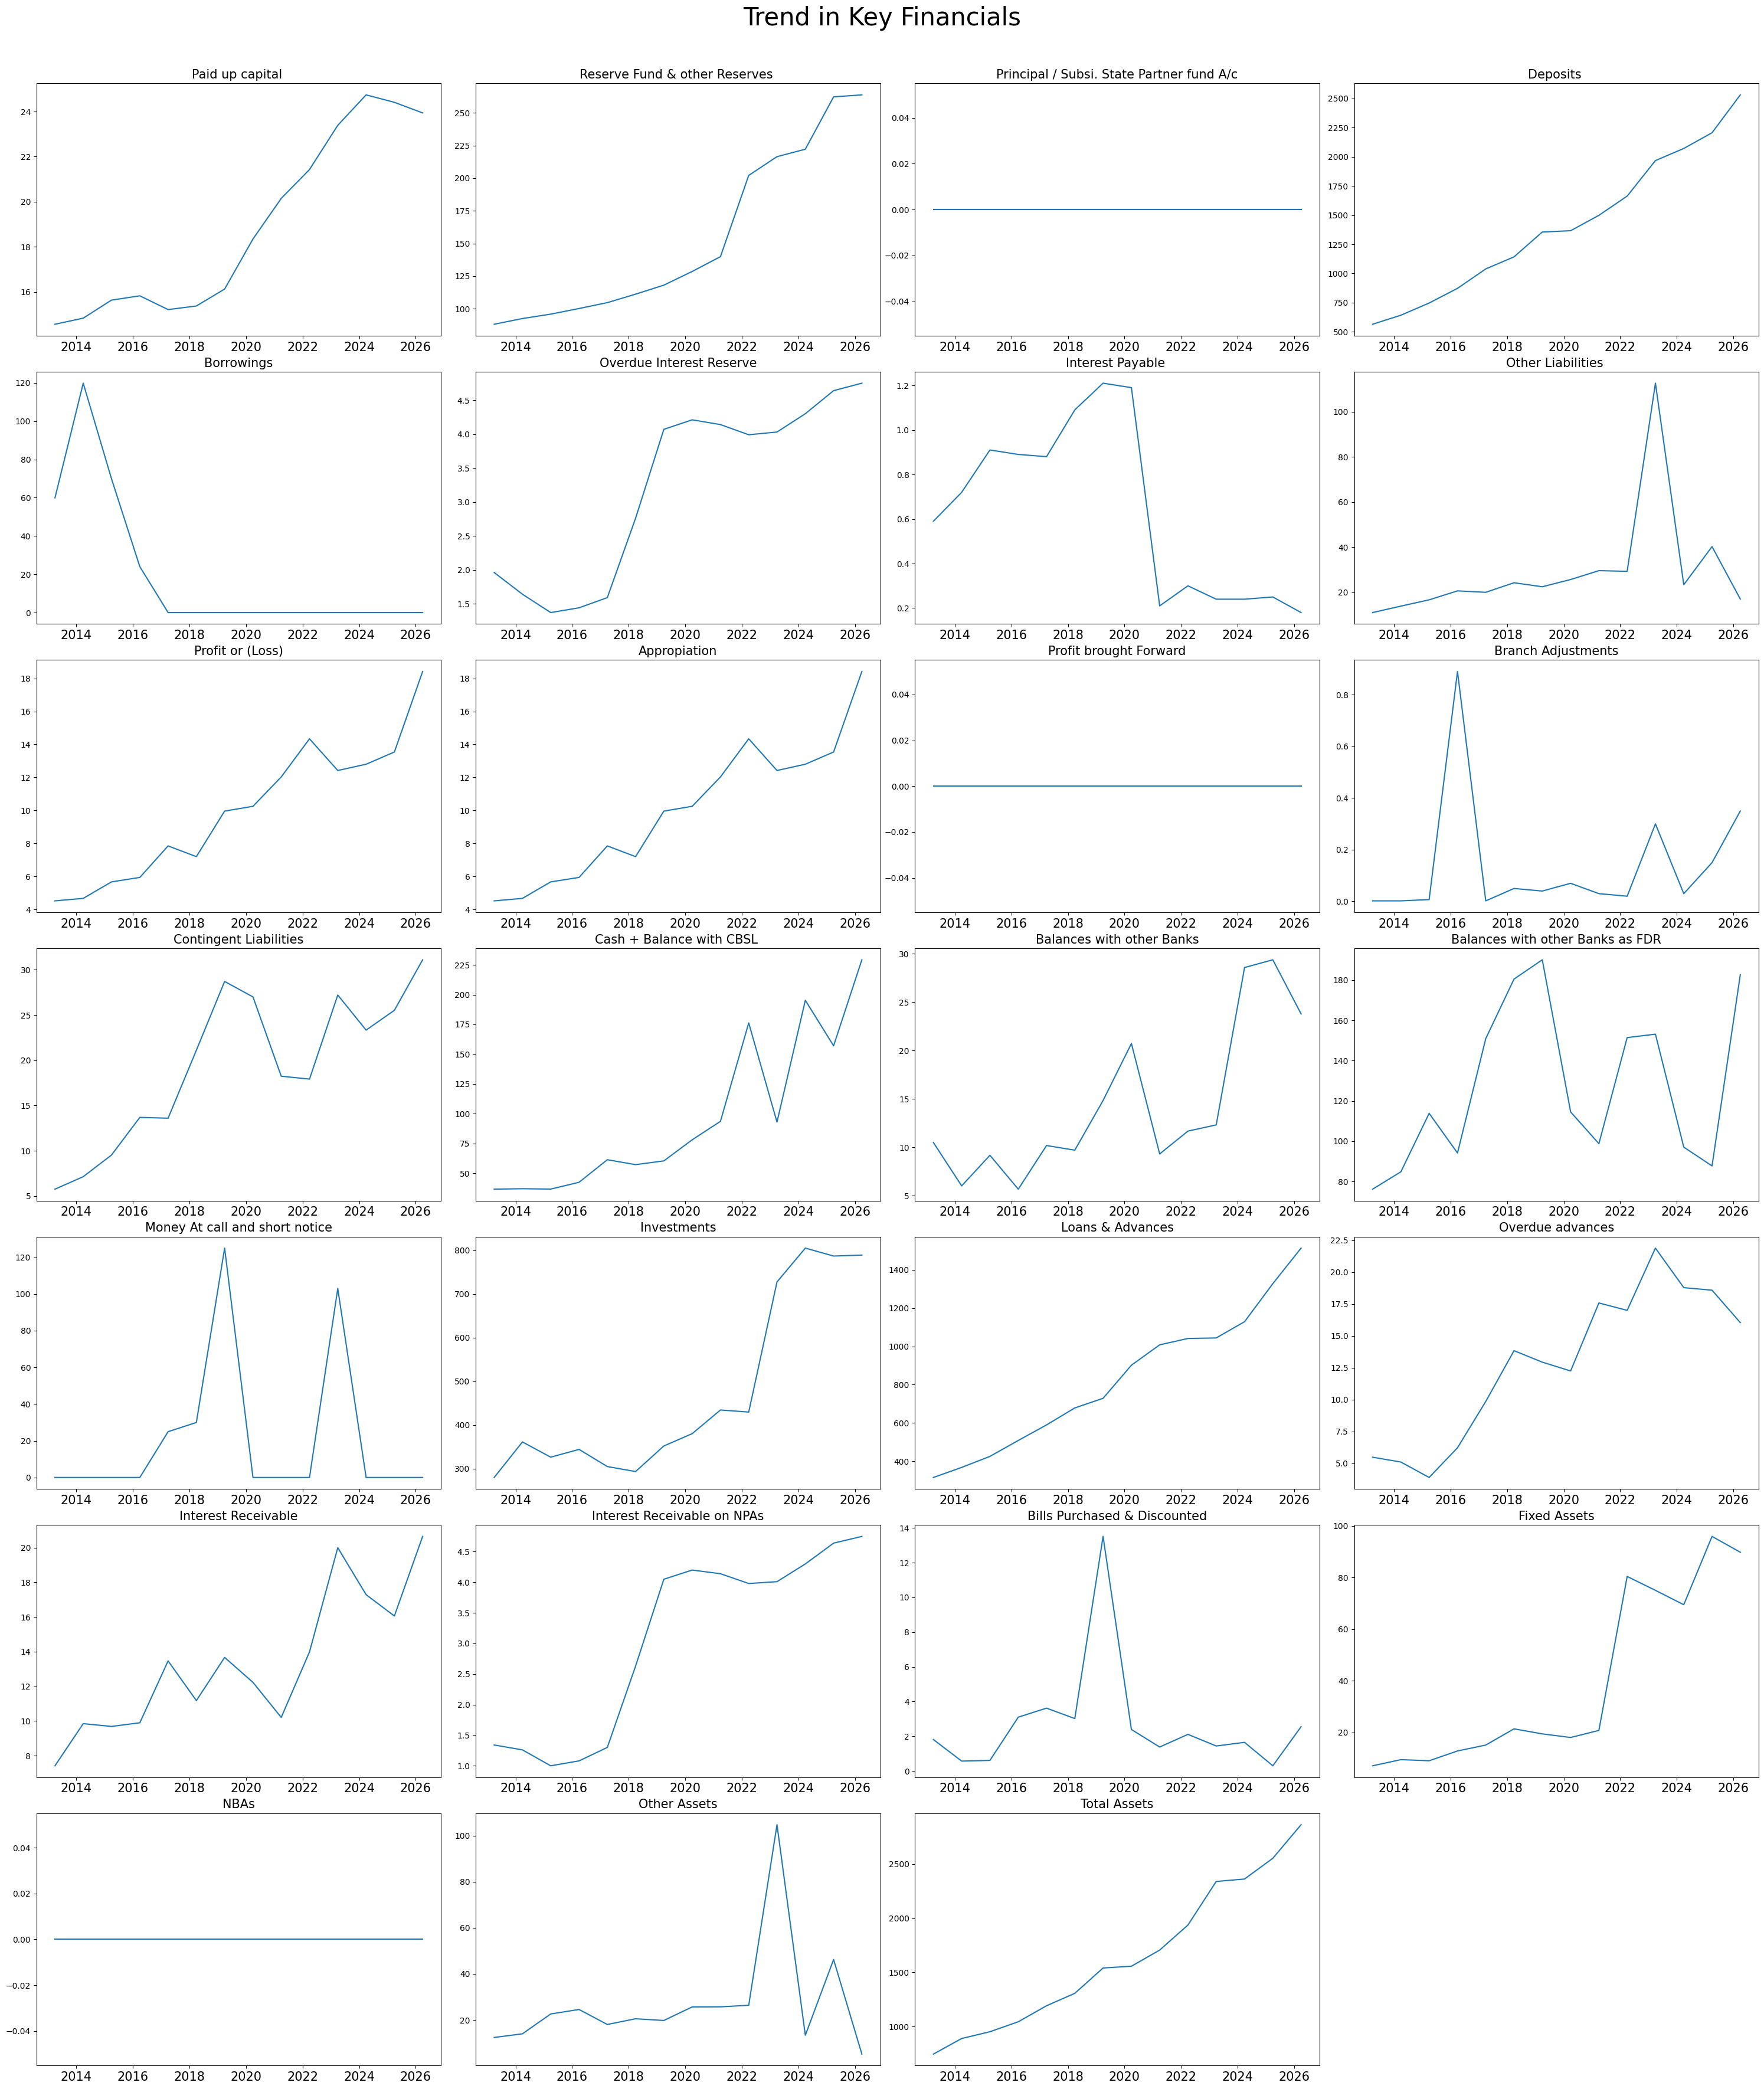

In [9]:
# plotting the timeseries plot of balance sheet items over the years

fig=plt.figure(figsize=(30,35))
#fig.tight_layout(h_pad= 0.5, w_pad= .5)

items = round(len(df2.index)/4)

for i in range(1,len(df2.index)+1):
    plt.subplot(items, 4, i)
    plt.plot(df2.columns,df2.iloc[i-1])
    plt.xticks(fontsize=15)
    plt.title(f'{df2.index[i-1]}', fontsize=15)

plt.suptitle('Trend in Key Financials',fontsize = 30, y = 1.01)
plt.tight_layout(h_pad=0.5, w_pad=0.5, rect=[0, 0, 1, 1])
plt.show()

# 2. Earnings Analysis

Here we disect the components of Return on Capital Employed (ROCE) into various sub-components to gain insight into sources and quality of earnings. A typical company's P&L can be viewed as consisting of following items:

Sales

-COGS
________________
**Gross Profit**

-SG&A
___________________
**Operating Profit**

-Depreciation & Provisions

__________________________
**EBIT**

-Interest paid
____________________________
**EBT**

-Taxes
_________________________
**Net Income**




However, in case of banks, Interest paid is treated as COGS since that is the cost paid by banks to generate sales i.e., earn income on its assets.

and ROCE is expressed as:


$$ROCE=\frac{EBIT} {Average\ Capital}$$



For an Urban Co-operative Bank, we make the following substitutions:

**Sales** = Interest Income + Other Income = **Total Income**

**EBIT** = Interest Income + Other Income - Interest Expense - Total Operating Exp - Provisions = **PBT**

**Average Capital** = (Opening Capital + Closing Capital)/2

**Average Total Assets** = (Opening Total Assets + Closing Total Assets)/2

And, we break the ROCE in sub-components to analyze the bank's income drivers:



$$ROCE= \frac {PBT} {Tot Income} \ X \  \frac {Tot Income} {Average\ Total\ Assets}  \ X \  \frac {Average\ Total\ Assets} {Average \ Capital}$$

In [10]:
# @title
# Reading the p&L data

df7=pd.read_excel(url,sheet_name='P&L',index_col=0, parse_dates=True)
df7.fillna(0)
df7['% change'] = np.round((np.divide(np.array(df7.iloc[:,-1:]), np.array(df7.iloc[:,-2:-1]))-1)*100,2)


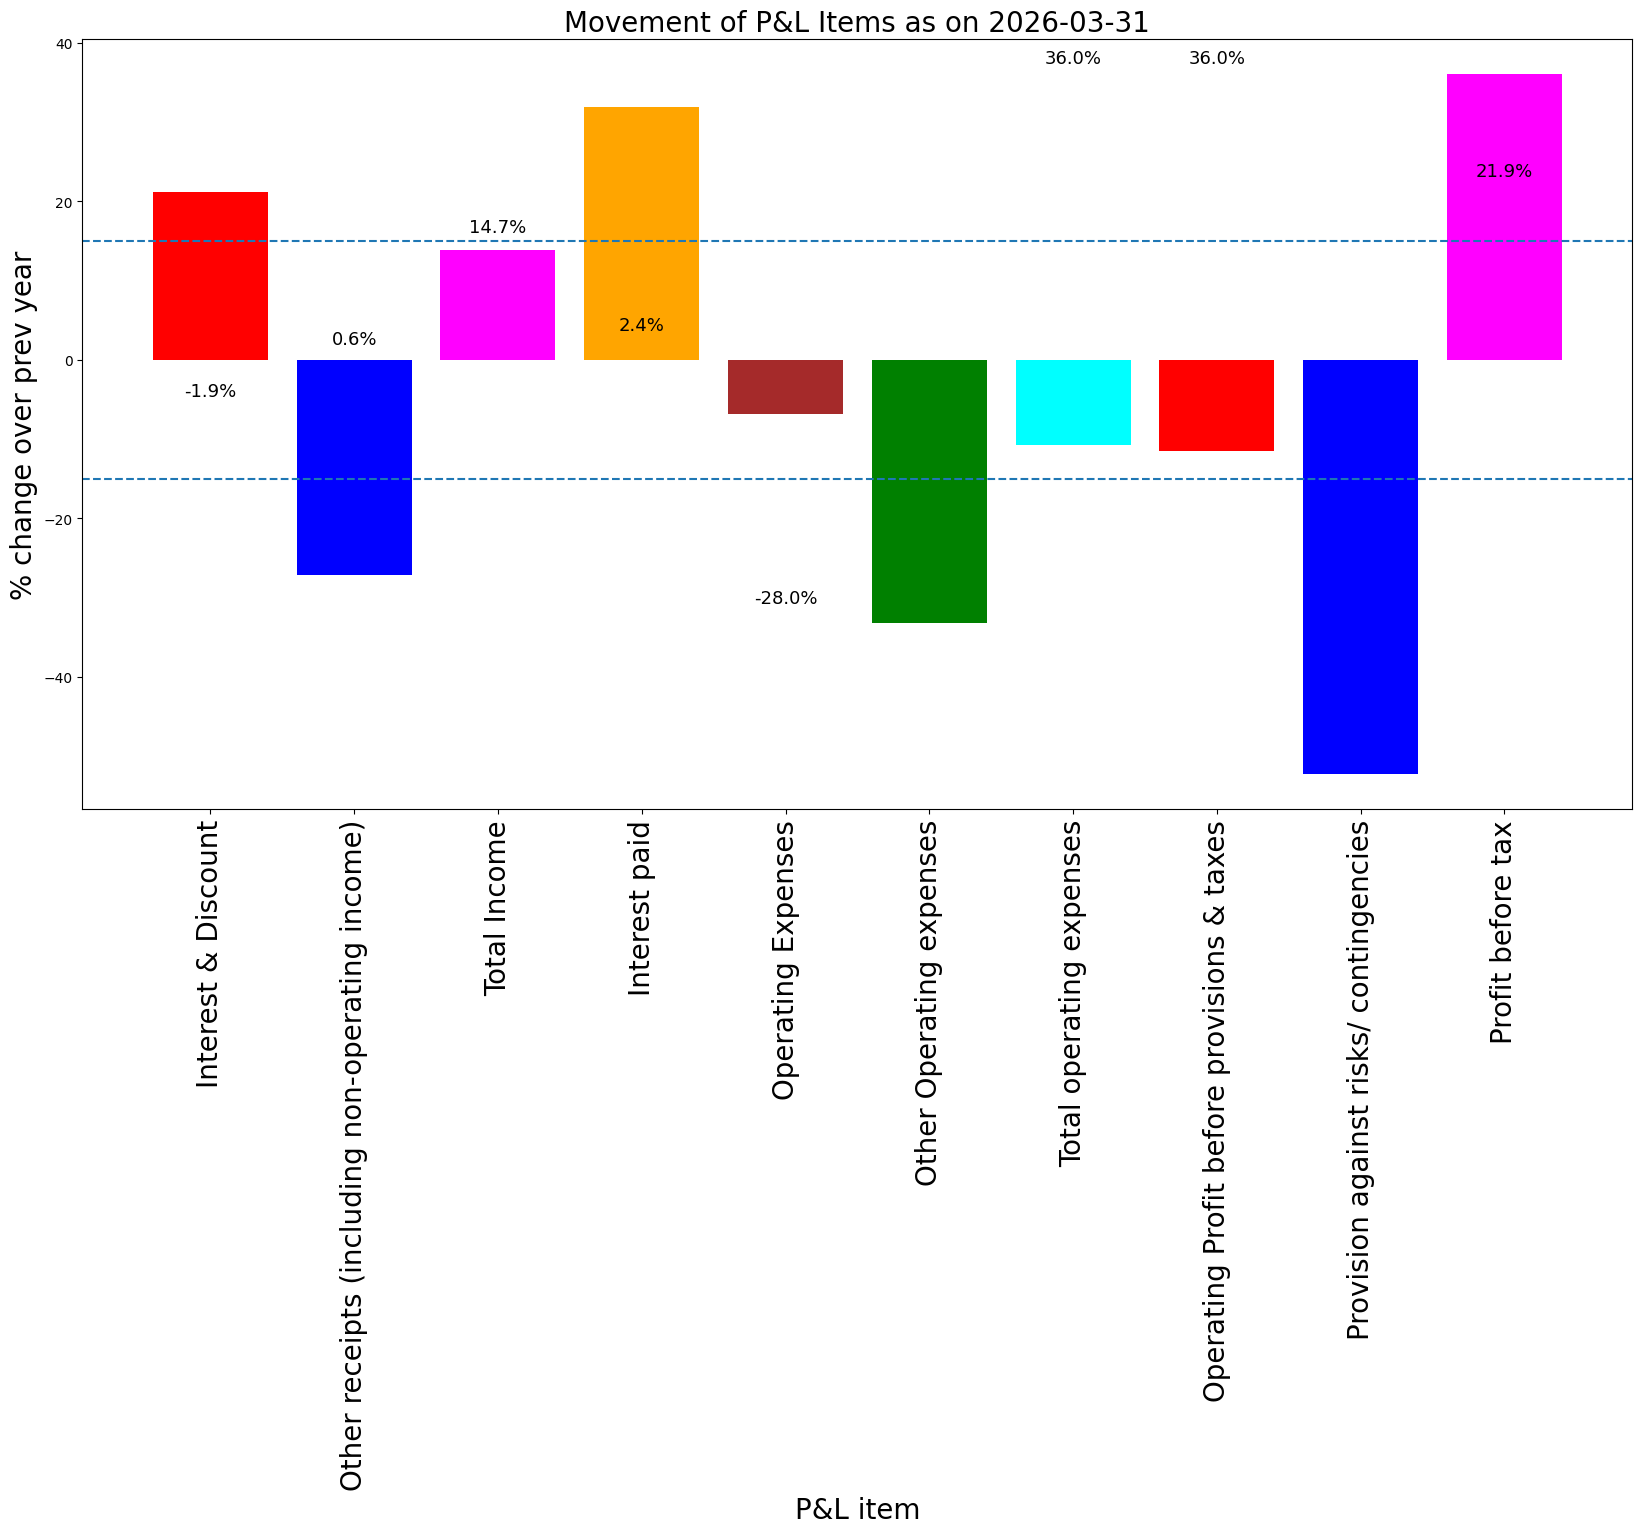

In [11]:
fig=plt.figure(figsize=(20,10))

c = ['red', 'blue', 'magenta', 'orange', 'brown', 'green', 'cyan']
plt.bar(df7.index[np.abs(df7['% change']!=0)], df7['% change'][np.abs(df7['% change']!=0)], color = c)

# Add value labels
plt.bar_label(bars, fmt='%.1f%%', padding=5, fontsize=13)

plt.xticks(rotation = 90, fontsize = 20)
plt.axhline(-15, linestyle = 'dashed')
plt.axhline(15, linestyle = 'dashed')
plt.title(f'Movement of P&L Items as on {df7.columns[-2].date()}', fontsize = 20)
plt.xlabel('P&L item', fontsize = 20)
plt.ylabel('% change over prev year', fontsize = 20)
plt.show()

In [12]:
df2

,2013-03-31,2014-03-31,2015-03-31,2016-03-31,2017-03-31,2018-03-31,2019-03-31,2020-03-31,2021-03-31,2022-03-31,2023-03-31,2024-03-31,2025-03-31,2026-03-31
ITEMS,,,,,,,,,,,,,,
Paid up capital,14.570,14.840,15.640,15.83,15.220,15.38,16.13,18.35,20.15,21.43,23.39,24.74,24.41,23.94
Reserve Fund & other Reserves,88.200,92.570,95.940,100.25,104.740,111.22,118.13,128.60,139.95,202.13,216.46,222.17,262.25,263.76
Principal / Subsi. State Partner fund A/c,0.000,0.000,0.000,0.00,0.000,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
Deposits,565.150,642.560,746.980,872.88,1039.180,1142.61,1355.43,1366.59,1498.51,1663.26,1967.72,2071.38,2206.13,2530.66
Borrowings,59.930,119.880,69.940,23.98,0.000,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
Overdue Interest Reserve,1.960,1.640,1.370,1.44,1.590,2.76,4.07,4.21,4.14,3.99,4.03,4.30,4.64,4.75
Interest Payable,0.590,0.720,0.910,0.89,0.880,1.09,1.21,1.19,0.21,0.30,0.24,0.24,0.25,0.18
Other Liabilities,11.060,13.910,16.700,20.66,20.030,24.26,22.49,25.69,29.62,29.32,112.66,23.39,40.27,17.03
Profit or (Loss),4.520,4.670,5.670,5.94,7.850,7.20,9.96,10.25,12.03,14.34,12.42,12.80,13.54,18.42


In [13]:
df2.index

Index(['Paid up capital ', 'Reserve Fund & other Reserves ',
       'Principal / Subsi. State Partner fund A/c', 'Deposits ', 'Borrowings',
       'Overdue Interest Reserve', 'Interest Payable ', 'Other Liabilities ',
       'Profit or (Loss)', 'Appropiation', 'Profit brought Forward',
       'Branch Adjustments', 'Contingent Liabilities',
       'Cash + Balance with CBSL ', 'Balances with other Banks',
       'Balances with other Banks as FDR', 'Money At call and short notice',
       'Investments', 'Loans & Advances', 'Overdue advances',
       'Interest Receivable', 'Interest Receivable on NPAs',
       'Bills Purchased & Discounted', 'Fixed Assets', 'NBAs', 'Other Assets',
       'Total Assets'],
      dtype='object', name='ITEMS')

In [14]:
# @title
# Creating P&L variables for analysis

df7.drop(['% change'], axis =1, inplace = True)
sales= df7.loc['Total Income']

PBT= sales - df7.loc['Interest paid']- df7.loc['Total operating expenses']- df7.loc['Provision against risks/ contingencies']

total_assets = df2.loc['Cash + Balance with CBSL ']+\
df2.loc['Balances with other Banks']+\
df2.loc['Balances with other Banks as FDR']+\
df2.loc['Money At call and short notice']+\
df2.loc['Investments']+df2.loc['Loans & Advances']+\
df2.loc['Interest Receivable']+\
df2.loc['Interest Receivable on NPAs']+\
df2.loc['Fixed Assets']+ df2.loc['NBAs'] + df2.loc['Other Assets']


capital= df2.loc['Paid up capital ']+ df2.loc['Reserve Fund & other Reserves ']


# Calculating average total asset as sum of opening and closing total asset

avg_total_assets={}
for i in range(1,len(df2.columns)):
    avg_total_assets[df2.columns[i]]=round((total_assets[i-1]+total_assets[i])/2,2)


avg_total_assets=list(avg_total_assets.values())
avg_total_assets.insert(0,0)


avg_total_capital={}
for j in range(1,len(df2.columns)):
    avg_total_capital[df2.columns[j]]=round((capital[j-1]+capital[j])/2,2)


avg_total_capital=list(avg_total_capital.values())
avg_total_capital.insert(0,0)

# Calculating the Ratios as sum of opening and closing total asset

PBT_to_Sales = PBT/sales

sales_to_avg_total_asset= sales/avg_total_assets

avg_assets_to_capital={}
for i in range(1,len(avg_total_assets)):
    avg_assets_to_capital[df2.columns[i]]= avg_total_assets[i]/avg_total_capital[i]

avg_assets_to_capital=list(avg_assets_to_capital.values())
avg_assets_to_capital.insert(0,0)

In [15]:
# @title
data=np.array([sales,PBT,avg_total_assets,avg_total_capital])
A=pd.DataFrame(data, columns=col_ind, index=['Sales','PBT','Avg_Tot_Assets','Avg_Tot_Capital'])

In [16]:
# @title
A

,2013-03-31,2014-03-31,2015-03-31,2016-03-31,2017-03-31,2018-03-31,2019-03-31,2020-03-31,2021-03-31,2022-03-31,2023-03-31,2024-03-31,2025-03-31,2026-03-31
Sales,60.54,76.30,91.59,101.39,116.13,120.38,128.20,139.20,145.03,162.16,171.38,171.91,188.40,214.56
PBT,4.52,4.67,5.67,5.94,7.85,7.20,9.96,10.25,12.03,14.34,12.42,12.80,13.54,18.42
Avg_Tot_Assets,0.00,818.38,921.98,997.96,1116.12,1246.98,1415.96,1541.20,1629.76,1819.66,2135.69,2347.81,2455.16,2704.86
Avg_Tot_Capital,0.00,105.09,109.50,113.83,118.02,123.28,130.43,140.60,153.52,191.83,231.70,243.38,266.79,287.18


In [17]:
# @title
ratio_data=np.array([PBT_to_Sales,sales_to_avg_total_asset,avg_assets_to_capital])

In [18]:
# @title
B=pd.DataFrame(ratio_data, columns=col_ind, index=['PBT/Income','Tot Income/Avg Assets','Avg Assets/Capital'])

In [19]:
# @title
C=B.iloc[:,1:len(B.columns)]

In [20]:
C

,2014-03-31,2015-03-31,2016-03-31,2017-03-31,2018-03-31,2019-03-31,2020-03-31,2021-03-31,2022-03-31,2023-03-31,2024-03-31,2025-03-31,2026-03-31
PBT/Income,0.061206,0.061906,0.058586,0.067597,0.059811,0.077691,0.073635,0.082948,0.088431,0.072471,0.074458,0.071868,0.085850
Tot Income/Avg Assets,0.093233,0.099341,0.101597,0.104048,0.096537,0.090539,0.090319,0.088989,0.089116,0.080246,0.073221,0.076736,0.079324
Avg Assets/Capital,7.787420,8.419909,8.767109,9.457041,10.115023,10.856091,10.961593,10.615946,9.485795,9.217479,9.646684,9.202594,9.418692


### 2.1 Return on Capital Employed (ROCE) Analysis

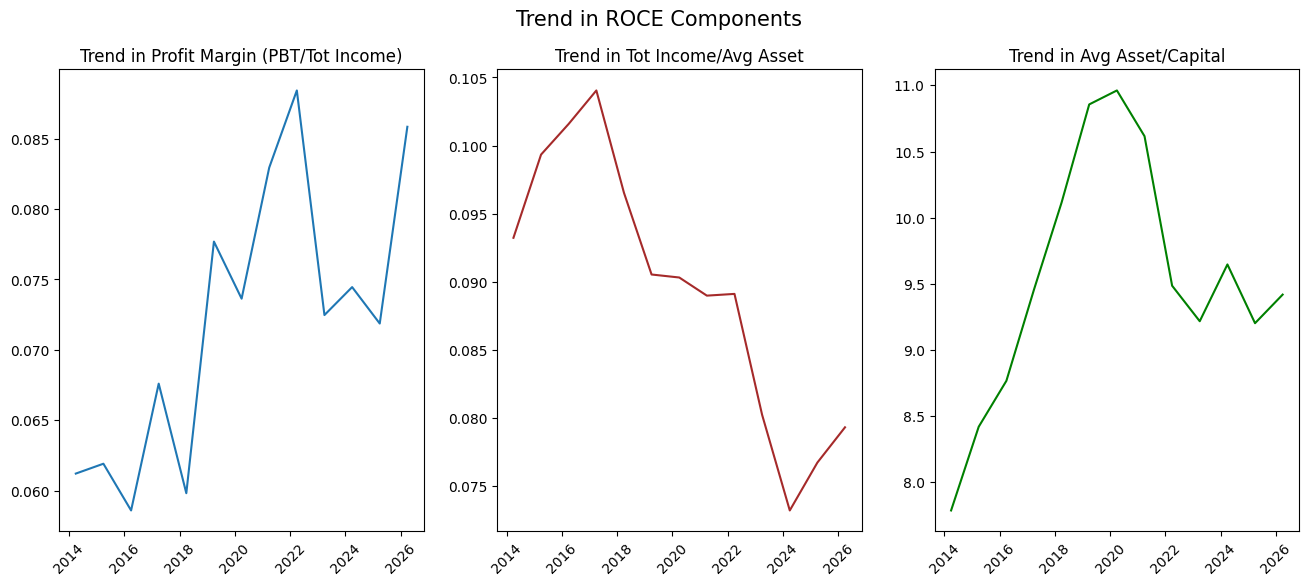

In [21]:
# @title
fig=plt.figure(figsize=(16,6))
fig.suptitle('Trend in ROCE Components', fontsize=15)

plt.subplot(1,3,1)
plt.plot(C.columns,C.iloc[0])
plt.title('Trend in Profit Margin (PBT/Tot Income)')
plt.xticks(rotation=45)

plt.subplot(1,3,2)
plt.plot(C.columns,C.iloc[1], color = 'brown')
plt.title('Trend in Tot Income/Avg Asset')
plt.xticks(rotation=45)

plt.subplot(1,3,3)
plt.plot(C.columns,C.iloc[2], color = 'green')
plt.title('Trend in Avg Asset/Capital')
plt.xticks(rotation=45)

plt.show()

### 2.2 Components of Profit Margin (PBT/Tot Income)

We further break PBT into sub-components to analyze the trend of the period:



$$ \frac {PBT} {Tot Income} = \frac {Interest\ Income} {Tot Income} \ + \  \frac {Other\ Receipts} {Tot Income}  \ - \  \frac {Interest Paid} {Tot Income} - \  \frac {Operating \ Expense} {Tot Income} - \  \frac {Other\ Operating\ Expense} {Tot Income} - \  \frac {Provision} {Tot Income} $$

In [22]:
# @title
df7

,2013-03-31 00:00:00,2014-03-31 00:00:00,2015-03-31 00:00:00,2016-03-31 00:00:00,2017-03-31 00:00:00,2018-03-31 00:00:00,2019-03-31 00:00:00,2020-03-31 00:00:00,2021-03-31 00:00:00,2022-03-31 00:00:00,2023-03-31 00:00:00,2024-03-31 00:00:00,2025-03-31 00:00:00,2026-03-31 00:00:00
Income,,,,,,,,,,,,,,
Interest & Discount,54.23,67.48,77.76,88.37,100.76,108.14,115.65,120.20,128.60,140.03,139.94,144.11,159.86,193.78
Other receipts (including non-operating income),6.31,8.82,13.83,13.02,15.37,12.24,12.55,19.00,16.43,22.13,31.44,27.80,28.54,20.78
Total Income,60.54,76.30,91.59,101.39,116.13,120.38,128.20,139.20,145.03,162.16,171.38,171.91,188.40,214.56
Interest paid,31.58,45.40,54.19,62.62,71.07,76.32,82.74,82.44,86.51,101.85,108.52,104.68,109.37,144.26
Operating Expenses,14.58,15.81,18.71,21.19,22.33,23.52,24.08,27.14,28.76,29.84,34.53,33.90,42.35,39.44
Other Operating expenses,2.42,2.53,2.69,2.79,3.38,5.02,5.64,7.40,5.64,6.41,6.65,12.67,7.35,4.91
Total operating expenses,17.00,18.34,21.40,23.98,25.71,28.54,29.72,34.54,34.40,36.25,41.18,46.57,49.70,44.35
Operating Profit before provisions & taxes,11.96,12.56,16.00,14.79,19.35,15.52,15.74,22.22,24.12,24.06,21.68,20.66,29.33,25.95
Provision against risks/ contingencies,7.44,7.89,10.33,8.85,11.50,8.32,5.78,11.97,12.09,9.72,9.26,7.86,15.79,7.53


In [23]:
# @title

Int_Income = df7.loc['Interest & Discount']
Int_Income_to_sales=Int_Income/sales
#print(Int_Income_to_sales)



Oth_receipts = df7.loc['Other receipts (including non-operating income)']
Oth_receipts_to_sales = Oth_receipts/sales
#print(Oth_receipts_to_sales)


Int_paid = df7.loc['Interest paid']
Int_paid_to_sales = Int_paid/sales
#print(Int_paid_to_sales)



Op_exp=df7.loc['Operating Expenses']
Op_exp_to_sales = Op_exp/sales
#print(Op_exp_to_sales)


Oth_op_exp=df7.loc['Other Operating expenses']
Oth_op_exp_to_sales=Oth_op_exp/sales
#print(Oth_op_exp_to_sales)


provision=df7.loc['Provision against risks/ contingencies']
provision_to_sales=provision/sales
#print(provision_to_sales)



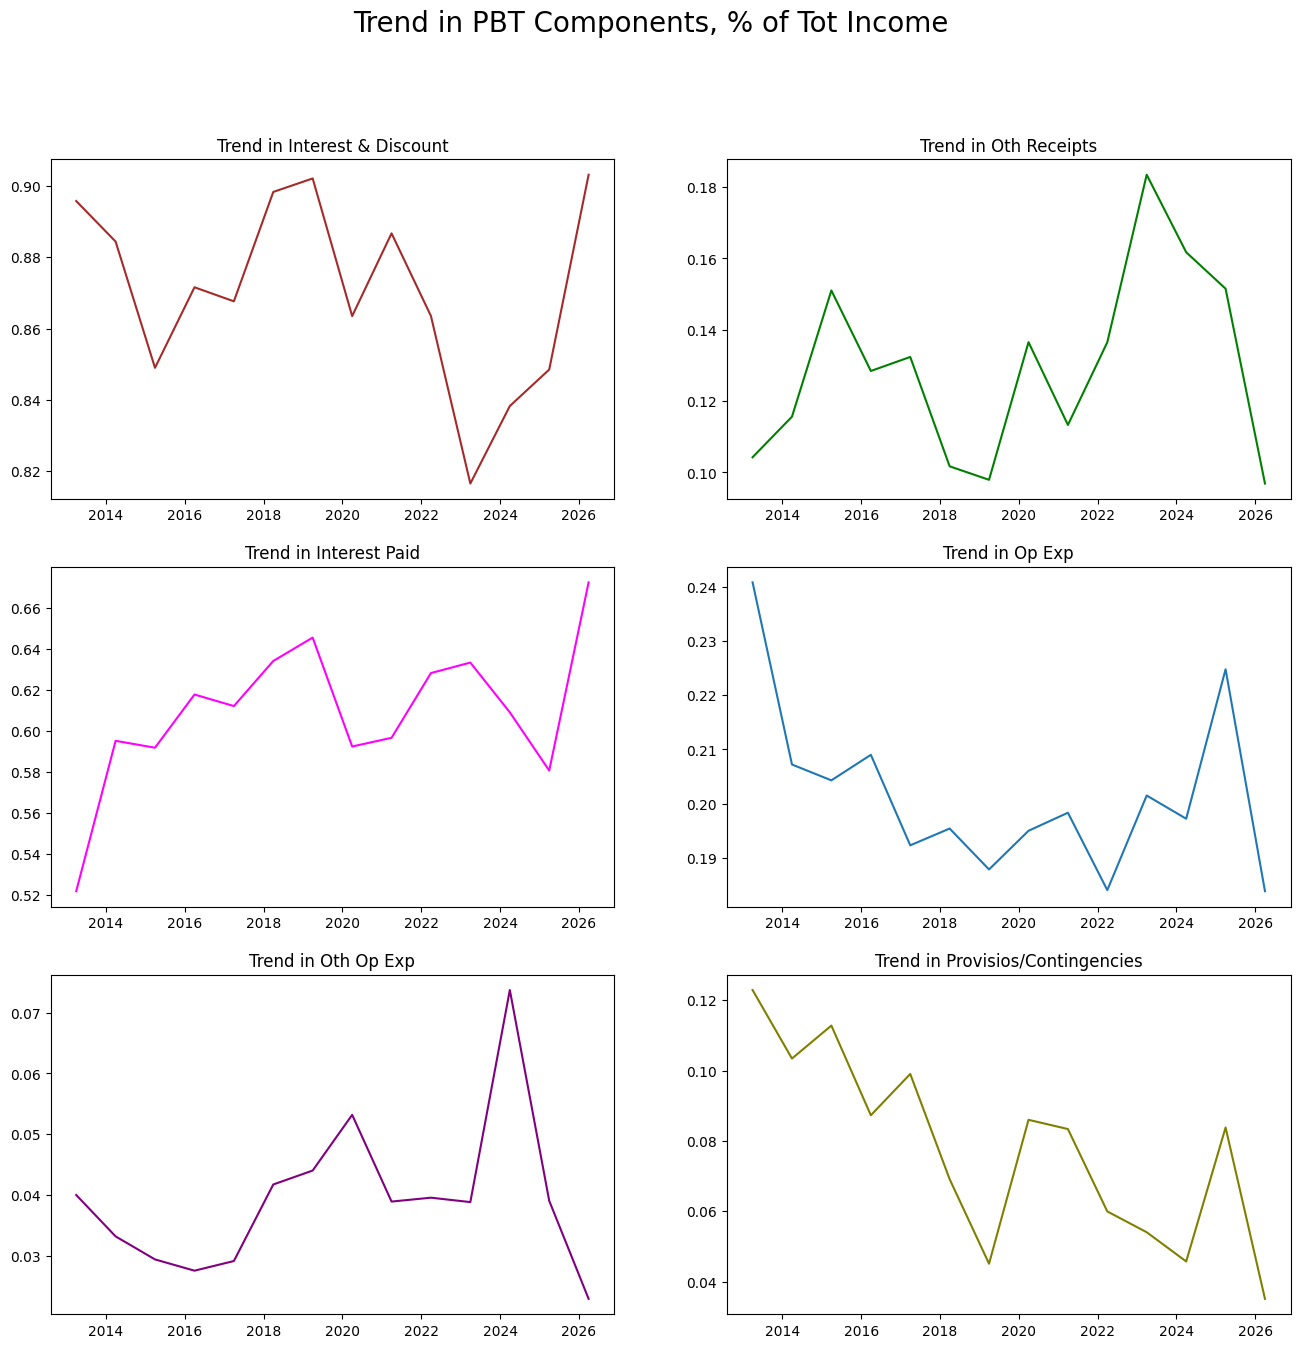

In [24]:
# @title
#Plotting trends in P&L Accounts

fig=plt.figure(figsize=(16,15))
fig.suptitle('Trend in PBT Components, % of Tot Income', fontsize=20)
fig.tight_layout(h_pad=10)

plt.subplot(3,2,1)
#plt.plot(data2.columns,data2.iloc[0], color = 'brown')
plt.plot(Int_Income_to_sales, color = 'brown')
plt.title('Trend in Interest & Discount')

plt.subplot(3,2,2)
plt.plot(Oth_receipts_to_sales, color = 'green')
plt.title('Trend in Oth Receipts')

plt.subplot(3,2,3)
plt.plot(Int_paid_to_sales, color = 'magenta')
plt.title('Trend in Interest Paid')

plt.subplot(3,2,4)
plt.plot(Op_exp_to_sales)
plt.title('Trend in Op Exp')

plt.subplot(3,2,5)
plt.plot(Oth_op_exp_to_sales, color = 'purple')
plt.title('Trend in Oth Op Exp')

plt.subplot(3,2,6)
plt.plot(provision_to_sales, color = 'olive')
plt.title('Trend in Provisios/Contingencies')

plt.show()